# HATPRO

## Instrumentation

Profiling radiometers like our HATPRO-G5 are mainly used to derive vertical profiles of atmospheric temperature and humidity.
The infrared radiometer extension allows to cloud base height and ice cloud detection.
The radiometer covers high-resolution temperature profiling of the boundary layer and low-humidity applications.
All models of the series provide accurate total amounts of atmospheric water vapor and cloud liquid water.
The retrieval algorithms is custom designed and  based on the long-term dataset of radiosondes at the GAIA-Airport.
Two bands, 22-31 GHz (7-channel filter-bank humidity profiler and LWP radiometer) and 51-58 GHz (7-channel filter-bank temperature profiler) are used in this radiometer.

Retrieved data types:
* vertical profiles of atmospheric temperature
* vertical profile of atmospheric humidity (relative and absolute humidity)
* Liquid Water Path (LWP)
* Integrated Water Vapor (IWV)

Since 2011 to 2017 we installed a Hatpro (SUNHAT) from University Cologne at our site. In 2017, we installed the first HATPRO-G5 (BCOHAT1) at the site.


In [51]:
import calendar

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

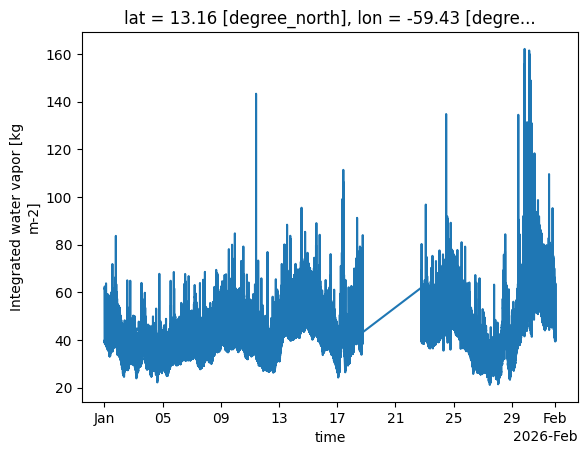

In [2]:
import intake
cat = intake.open_catalog("https://tcodata.mpimet.mpg.de/catalog.yaml")
ds = cat.BCO.radiometer_HATPRO_IWV_c1_v1.to_dask()
ds.sel(time="2026-01").IWV.plot(x="time")

In [3]:
ds

<xarray.Dataset> Size: 3GB
Dimensions:     (time: 135627253)
Coordinates:
    lat         float64 8B ...
    lon         float64 8B ...
    sensor_alt  float64 8B ...
  * time        (time) datetime64[ns] 1GB 2017-10-01T00:04:17 ... 2026-05-13T...
Data variables:
    AZI         (time) float32 543MB dask.array<chunksize=(262144,), meta=np.ndarray>
    ELE         (time) float32 543MB dask.array<chunksize=(262144,), meta=np.ndarray>
    IWV         (time) float32 543MB dask.array<chunksize=(262144,), meta=np.ndarray>
    RF          (time) int8 136MB dask.array<chunksize=(262144,), meta=np.ndarray>
    SF          (time) int8 136MB dask.array<chunksize=(262144,), meta=np.ndarray>
Attributes:
    Conventions:           CF-1.12
    _logical_cutoff_date:  2026-05-13T00:00:00Z
    bcoproc_version:       0.0.0.post1185.dev0+c830e01
    featureType:           timeSeries
    institution:           Max Planck Institute for Meteorology, Hamburg
    license:               CC0-1.0
    location:              The Barbados Cloud Observatory (BCO), Deebles Poin...
    platform:              BCO
    source:                HATPRO microwave radiometer
    summary:               This dataset contains measurements of the microwav...
    title:                 Microwave radiometer (HATPRO) data from BCO (Level 1)
    tool_versions:         {"Python": "3.11.2 (main, Apr 28 2025, 14:11:48) [...

In [4]:
IWV = ds['IWV'].compute()

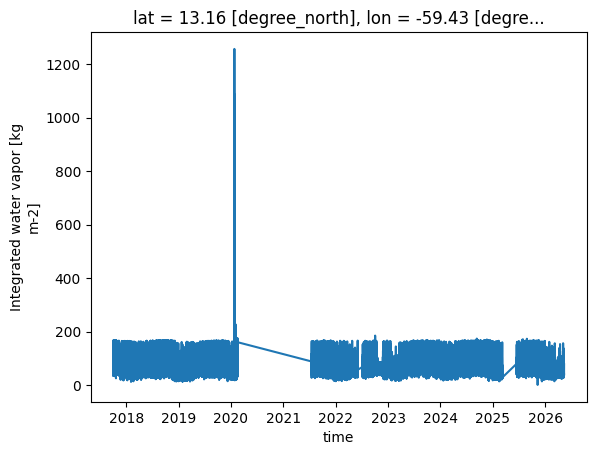

In [5]:
IWV.plot()

### Comments from plot
- There is a huge spike in early 2020 six times greater than any other time.
- There is a big gap from 2020 to mid 2021.
- There is another small gap in early 2025.
- There are possible gaps and low values from 2022-04 to 2023-03.

### Faceting for Each month of year

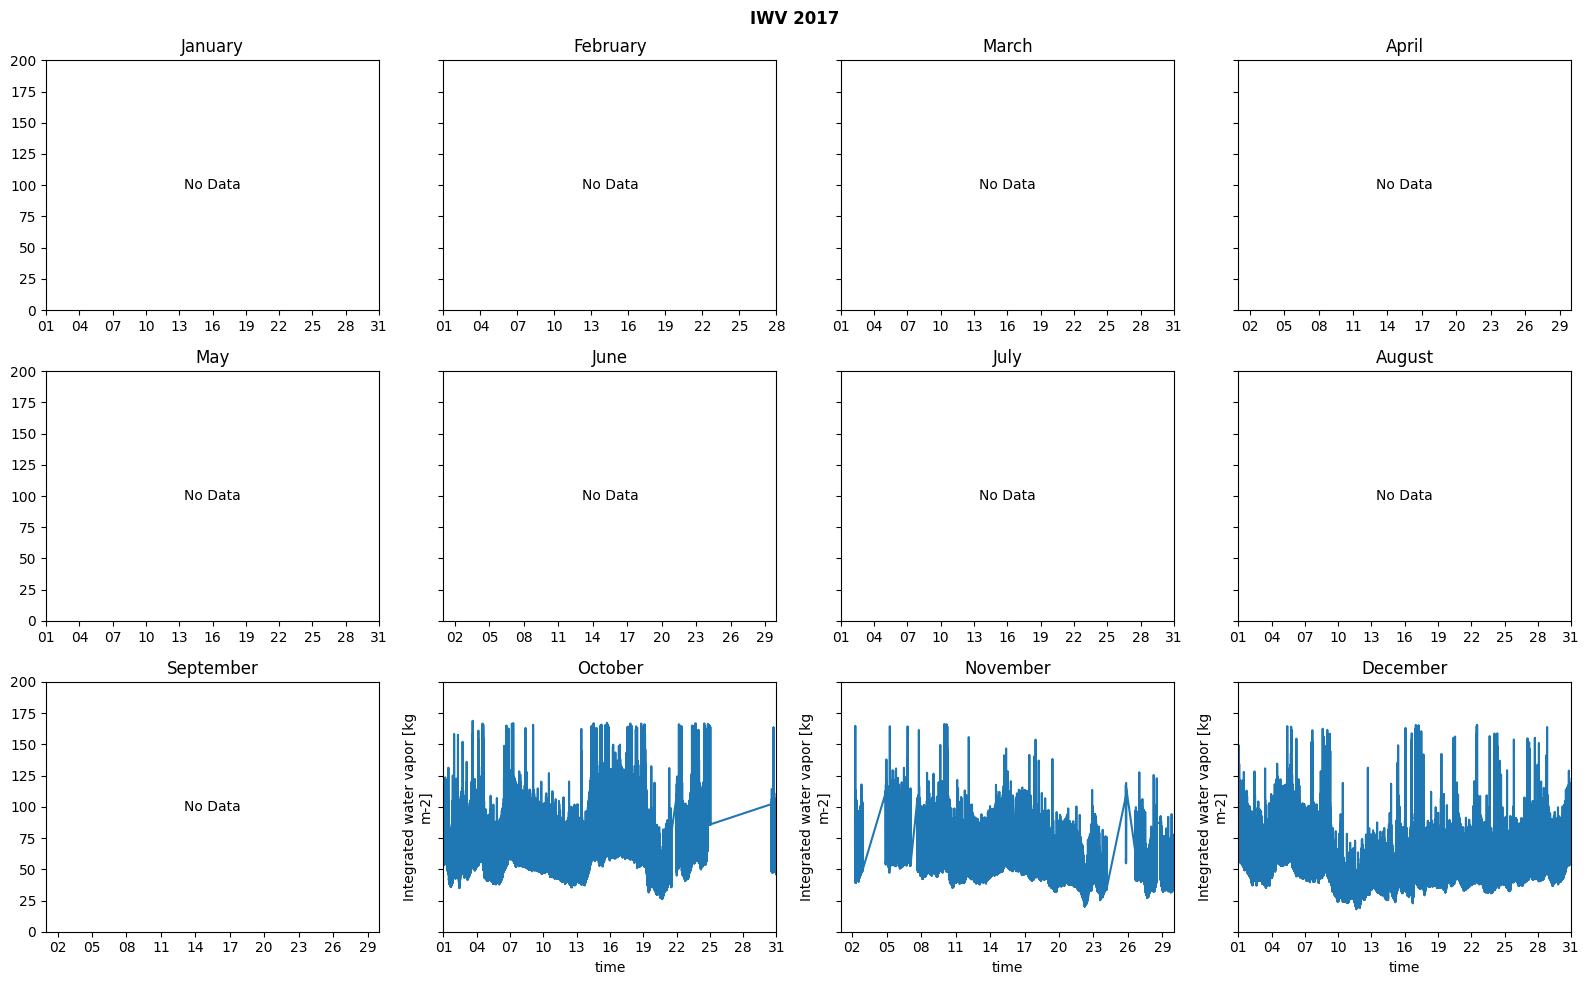

In [50]:
import calendar
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Select year
year = 2017
iwv_2017 = IWV.sel(time=str(year))

# Group by month
groups = iwv_2017.groupby('time.month')

# Create faceted plots
fig, axes = plt.subplots(
    3, 4,
    figsize=(16, 10),
    sharey=True
)

axes = axes.flatten()

# Plot each month
for month, ax in zip(range(1, 13), axes):

    # First and last day
    start_date = np.datetime64(f'{year}-{month:02d}-01')

    last_day = calendar.monthrange(year, month)[1]

    end_date = np.datetime64(
        f'{year}-{month:02d}-{last_day:02d}'
    )

    # If month exists
    if month in groups.groups:

        groups[month].plot(
            ax=ax,
            x='time'
        )

    # Empty month
    else:

        ax.plot(
            [start_date, end_date],
            [np.nan, np.nan],
            alpha=0
        )

        ax.text(
            0.5, 0.5,
            'No Data',
            ha='center',
            va='center',
            transform=ax.transAxes
        )

    # Axis formatting
    ax.set_xlim(start_date, end_date)

    ax.set_ylim(0, 200)

    ax.set_title(
        calendar.month_name[month],
        fontweight='medium'
    )

    # Better date ticks
    ax.xaxis.set_major_locator(
        mdates.DayLocator(interval=3)
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%d')
    )

    ax.tick_params(
        axis='x',
        rotation=0
    )

fig.suptitle(
    f'IWV {year}',
    fontweight='bold'
)

plt.tight_layout()

plt.show()

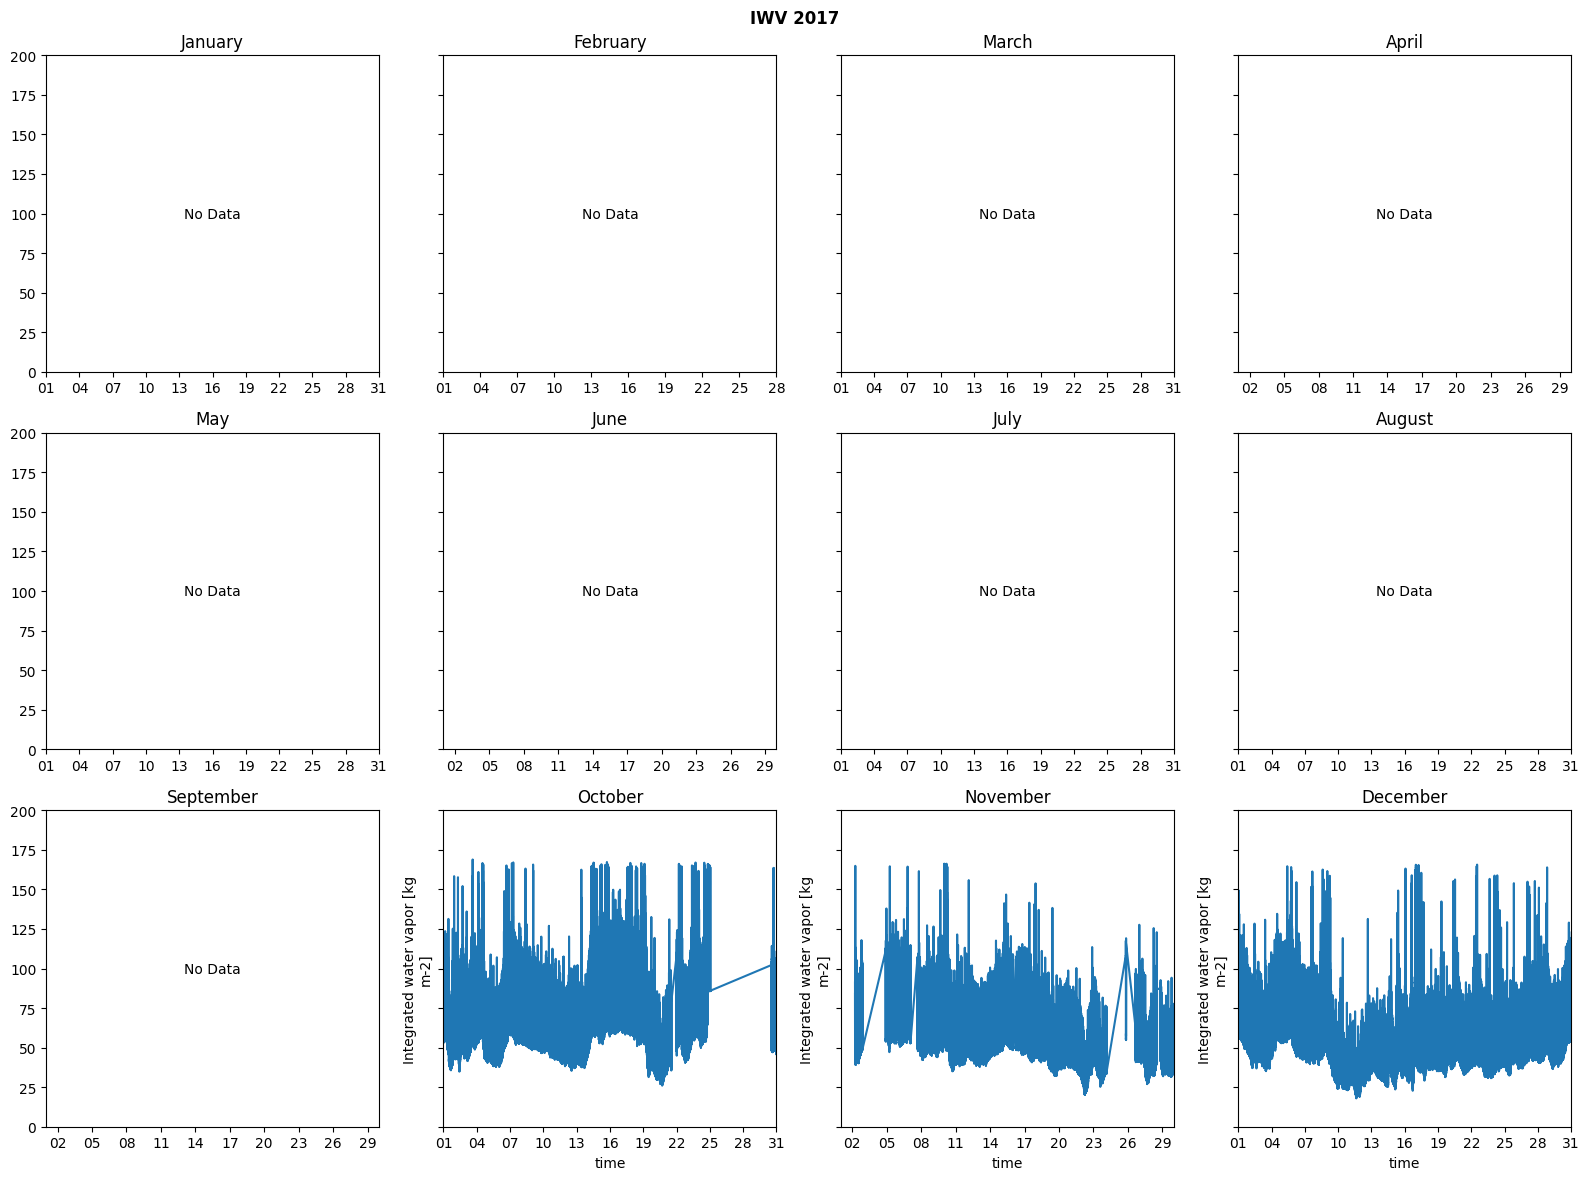

In [55]:
# Select year.
year = 2017
iwv_2017 = IWV.sel(time=str(year))

# Group by month
groups = iwv_2017.groupby('time.month')

# Create faceted plots manually.
fig, axes = plt.subplots(3, 4, figsize=(16, 12), sharey=True)
axes = axes.flatten()

# Plot each month
for month, ax in zip(range(1, 13), axes):

    # First and last day of month.
    start_date = np.datetime64(f'{year}-{month:02d}-01')
    last_day = calendar.monthrange(year, month)[1]
    end_date = np.datetime64(f'{year}-{month:02d}-{last_day:02d}')

    # If month exists.
    if month in groups.groups:
        groups[month].plot(ax=ax, x='time')

    else:
        ax.text(
            0.5, 0.5,
            'No Data',
            ha='center',
            va='center',
            transform=ax.transAxes
        )

    # Axis formatting.
    ax.set_xlim(start_date, end_date)
    ax.set_ylim(0, 200)
    ax.set_title(calendar.month_name[month], fontweight='medium')

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))

fig.suptitle(f'IWV {year}', fontweight='bold')

plt.tight_layout()
plt.show()

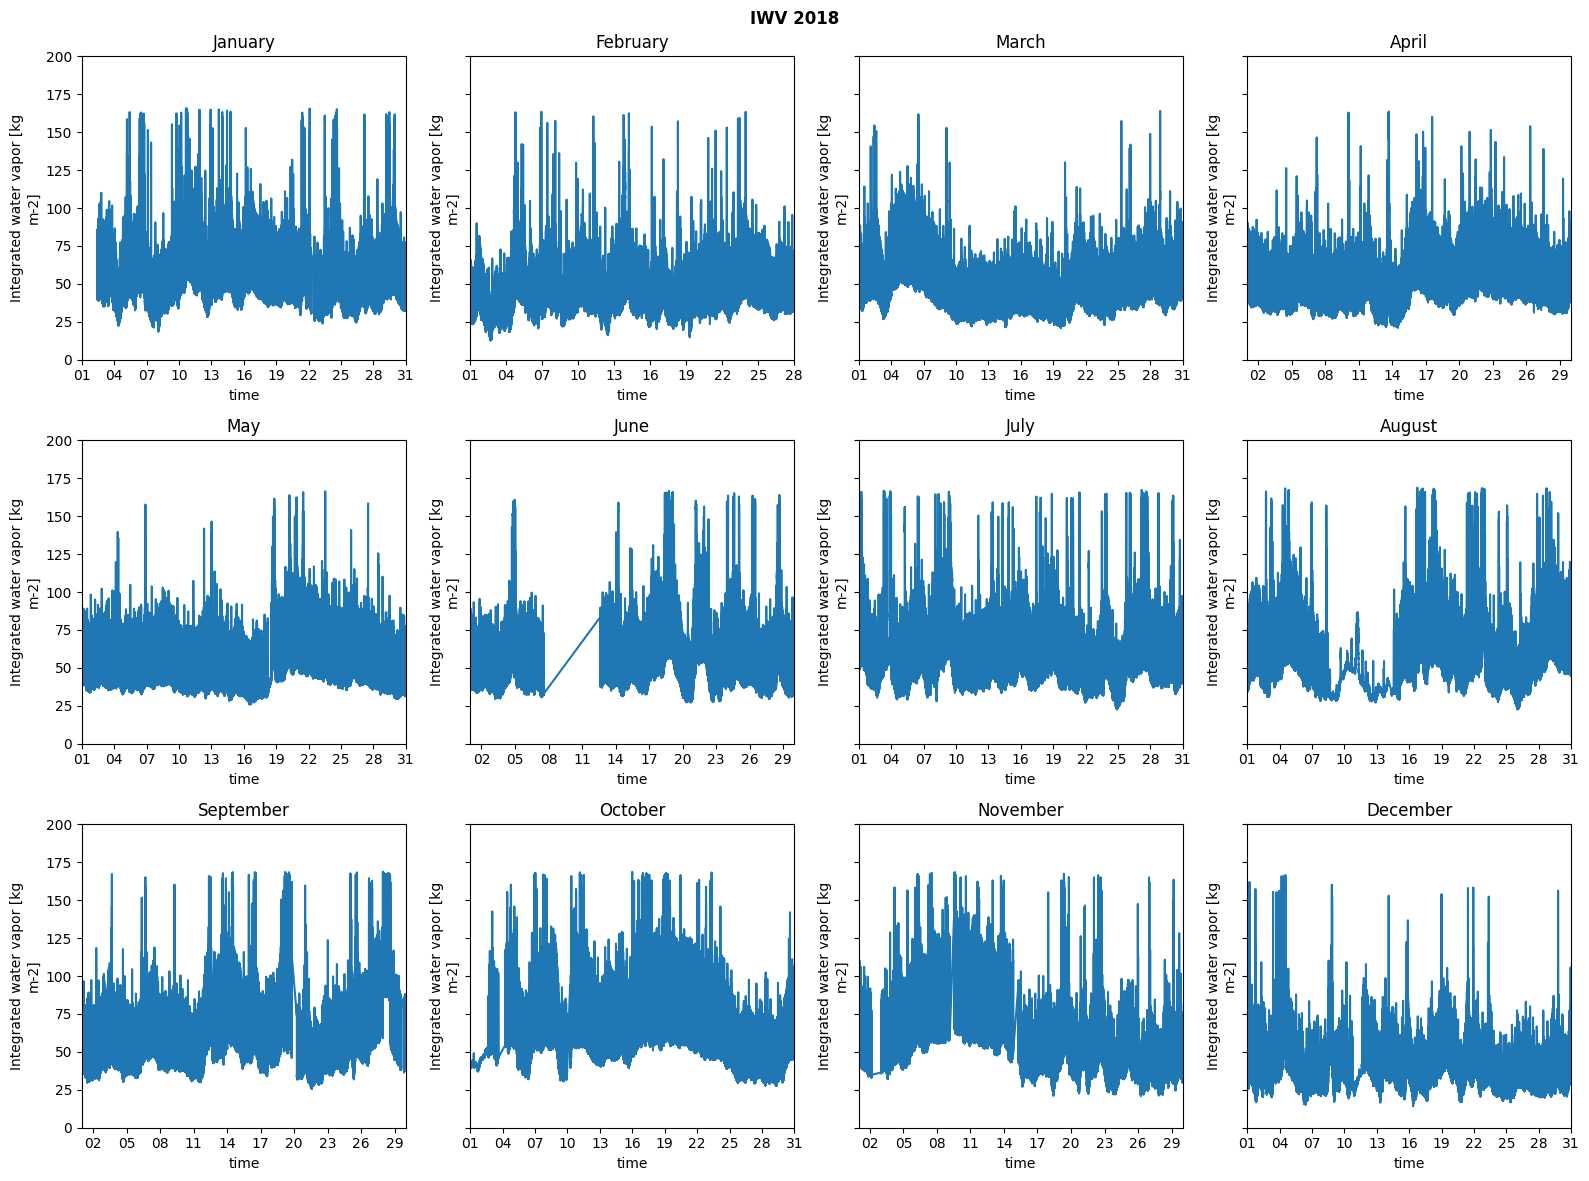

In [56]:
# Select year.
year = 2018
iwv_2018 = IWV.sel(time=str(year))

# Group by month
groups = iwv_2018.groupby('time.month')

# Create faceted plots manually.
fig, axes = plt.subplots(3, 4, figsize=(16, 12), sharey=True)
axes = axes.flatten()

# Plot each month
for month, ax in zip(range(1, 13), axes):

    # First and last day of month.
    start_date = np.datetime64(f'{year}-{month:02d}-01')
    last_day = calendar.monthrange(year, month)[1]
    end_date = np.datetime64(f'{year}-{month:02d}-{last_day:02d}')

    # If month exists.
    if month in groups.groups:
        groups[month].plot(ax=ax, x='time')

    else:
        ax.text(
            0.5, 0.5,
            'No Data',
            ha='center',
            va='center',
            transform=ax.transAxes
        )

    # Axis formatting.
    ax.set_xlim(start_date, end_date)
    ax.set_ylim(0, 200)
    ax.set_title(calendar.month_name[month], fontweight='medium')

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))

fig.suptitle(f'IWV {year}', fontweight='bold')

plt.tight_layout()
plt.show()

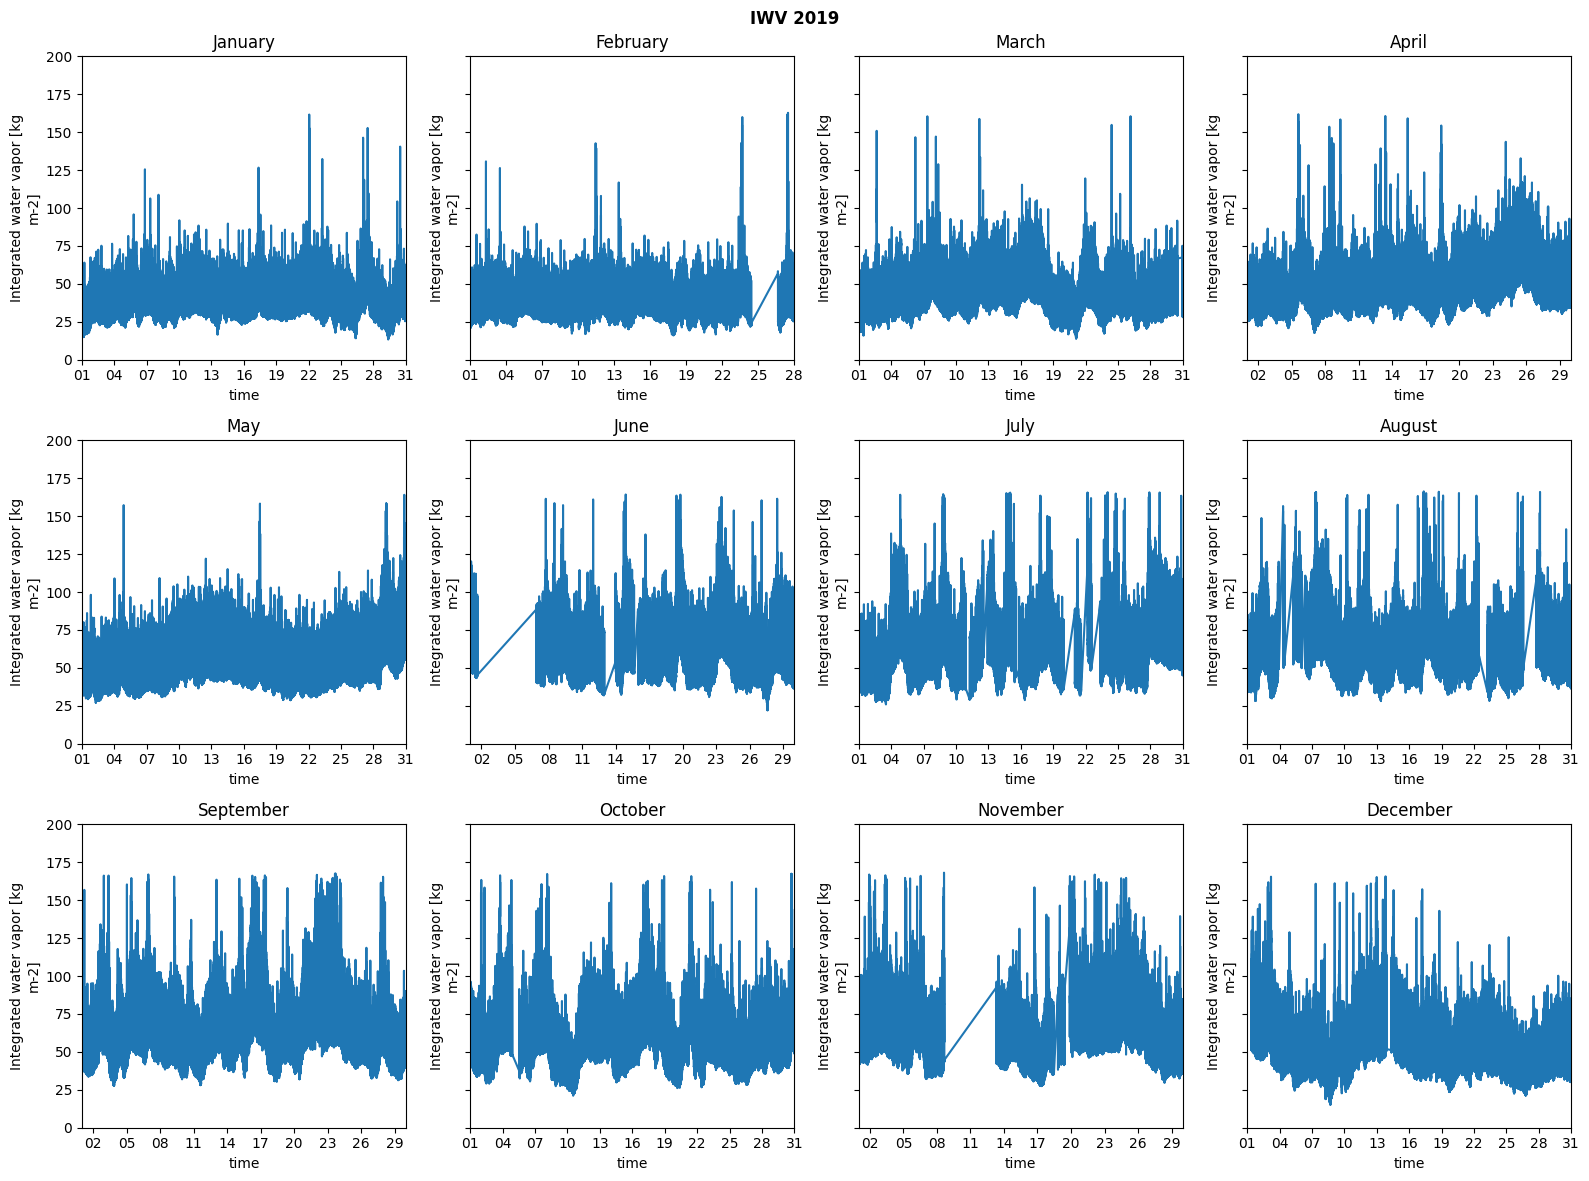

In [57]:
# Select year.
year = 2019
iwv_2019 = IWV.sel(time=str(year))

# Group by month
groups = iwv_2019.groupby('time.month')

# Create faceted plots manually.
fig, axes = plt.subplots(3, 4, figsize=(16, 12), sharey=True)
axes = axes.flatten()

# Plot each month
for month, ax in zip(range(1, 13), axes):

    # First and last day of month.
    start_date = np.datetime64(f'{year}-{month:02d}-01')
    last_day = calendar.monthrange(year, month)[1]
    end_date = np.datetime64(f'{year}-{month:02d}-{last_day:02d}')

    # If month exists.
    if month in groups.groups:
        groups[month].plot(ax=ax, x='time')

    else:
        ax.text(
            0.5, 0.5,
            'No Data',
            ha='center',
            va='center',
            transform=ax.transAxes
        )

    # Axis formatting.
    ax.set_xlim(start_date, end_date)
    ax.set_ylim(0, 200)
    ax.set_title(calendar.month_name[month], fontweight='medium')

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))

fig.suptitle(f'IWV {year}', fontweight='bold')

plt.tight_layout()
plt.show()

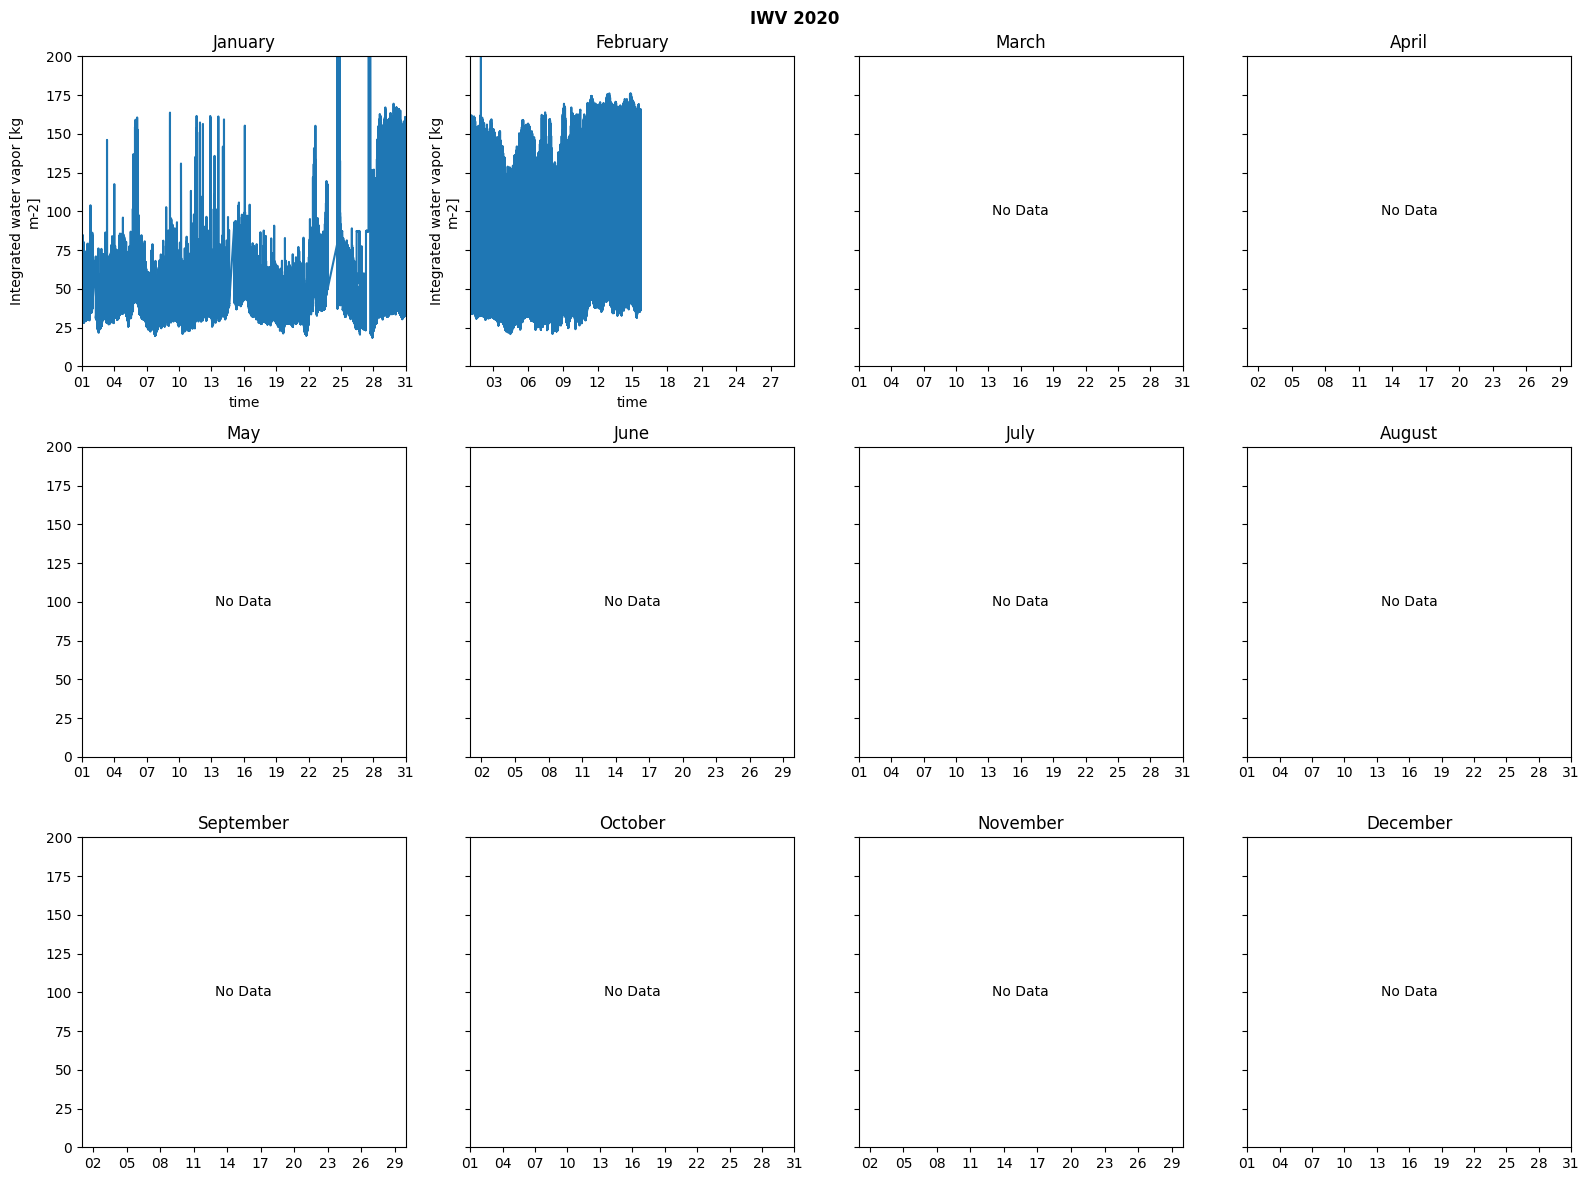

In [58]:
# Select year.
year = 2020
iwv_2020 = IWV.sel(time=str(year))

# Group by month
groups = iwv_2020.groupby('time.month')

# Create faceted plots manually.
fig, axes = plt.subplots(3, 4, figsize=(16, 12), sharey=True)
axes = axes.flatten()

# Plot each month
for month, ax in zip(range(1, 13), axes):

    # First and last day of month.
    start_date = np.datetime64(f'{year}-{month:02d}-01')
    last_day = calendar.monthrange(year, month)[1]
    end_date = np.datetime64(f'{year}-{month:02d}-{last_day:02d}')

    # If month exists.
    if month in groups.groups:
        groups[month].plot(ax=ax, x='time')

    else:
        ax.text(
            0.5, 0.5,
            'No Data',
            ha='center',
            va='center',
            transform=ax.transAxes
        )

    # Axis formatting.
    ax.set_xlim(start_date, end_date)
    ax.set_ylim(0, 200)
    ax.set_title(calendar.month_name[month], fontweight='medium')

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))

fig.suptitle(f'IWV {year}', fontweight='bold')

plt.tight_layout()
plt.show()

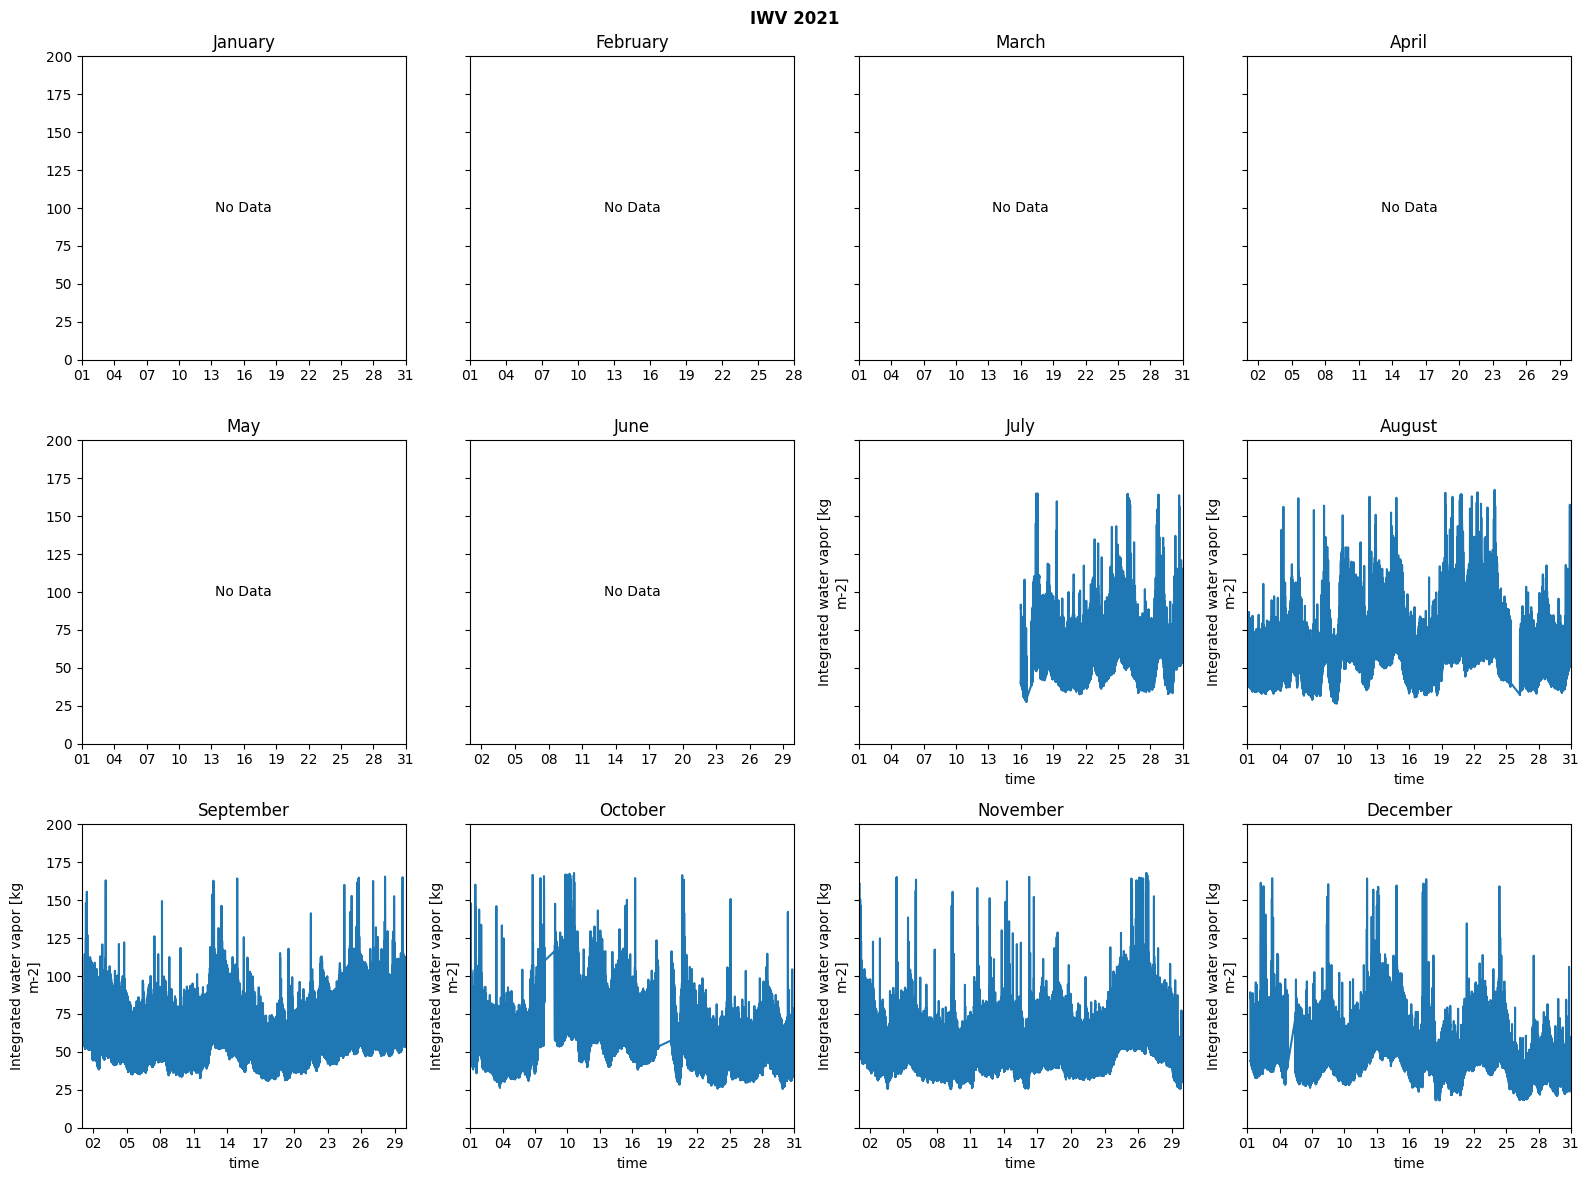

In [59]:
# Select year.
year = 2021
iwv_2021 = IWV.sel(time=str(year))

# Group by month
groups = iwv_2021.groupby('time.month')

# Create faceted plots manually.
fig, axes = plt.subplots(3, 4, figsize=(16, 12), sharey=True)
axes = axes.flatten()

# Plot each month
for month, ax in zip(range(1, 13), axes):

    # First and last day of month.
    start_date = np.datetime64(f'{year}-{month:02d}-01')
    last_day = calendar.monthrange(year, month)[1]
    end_date = np.datetime64(f'{year}-{month:02d}-{last_day:02d}')

    # If month exists.
    if month in groups.groups:
        groups[month].plot(ax=ax, x='time')

    else:
        ax.text(
            0.5, 0.5,
            'No Data',
            ha='center',
            va='center',
            transform=ax.transAxes
        )

    # Axis formatting.
    ax.set_xlim(start_date, end_date)
    ax.set_ylim(0, 200)
    ax.set_title(calendar.month_name[month], fontweight='medium')

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))

fig.suptitle(f'IWV {year}', fontweight='bold')

plt.tight_layout()
plt.show()

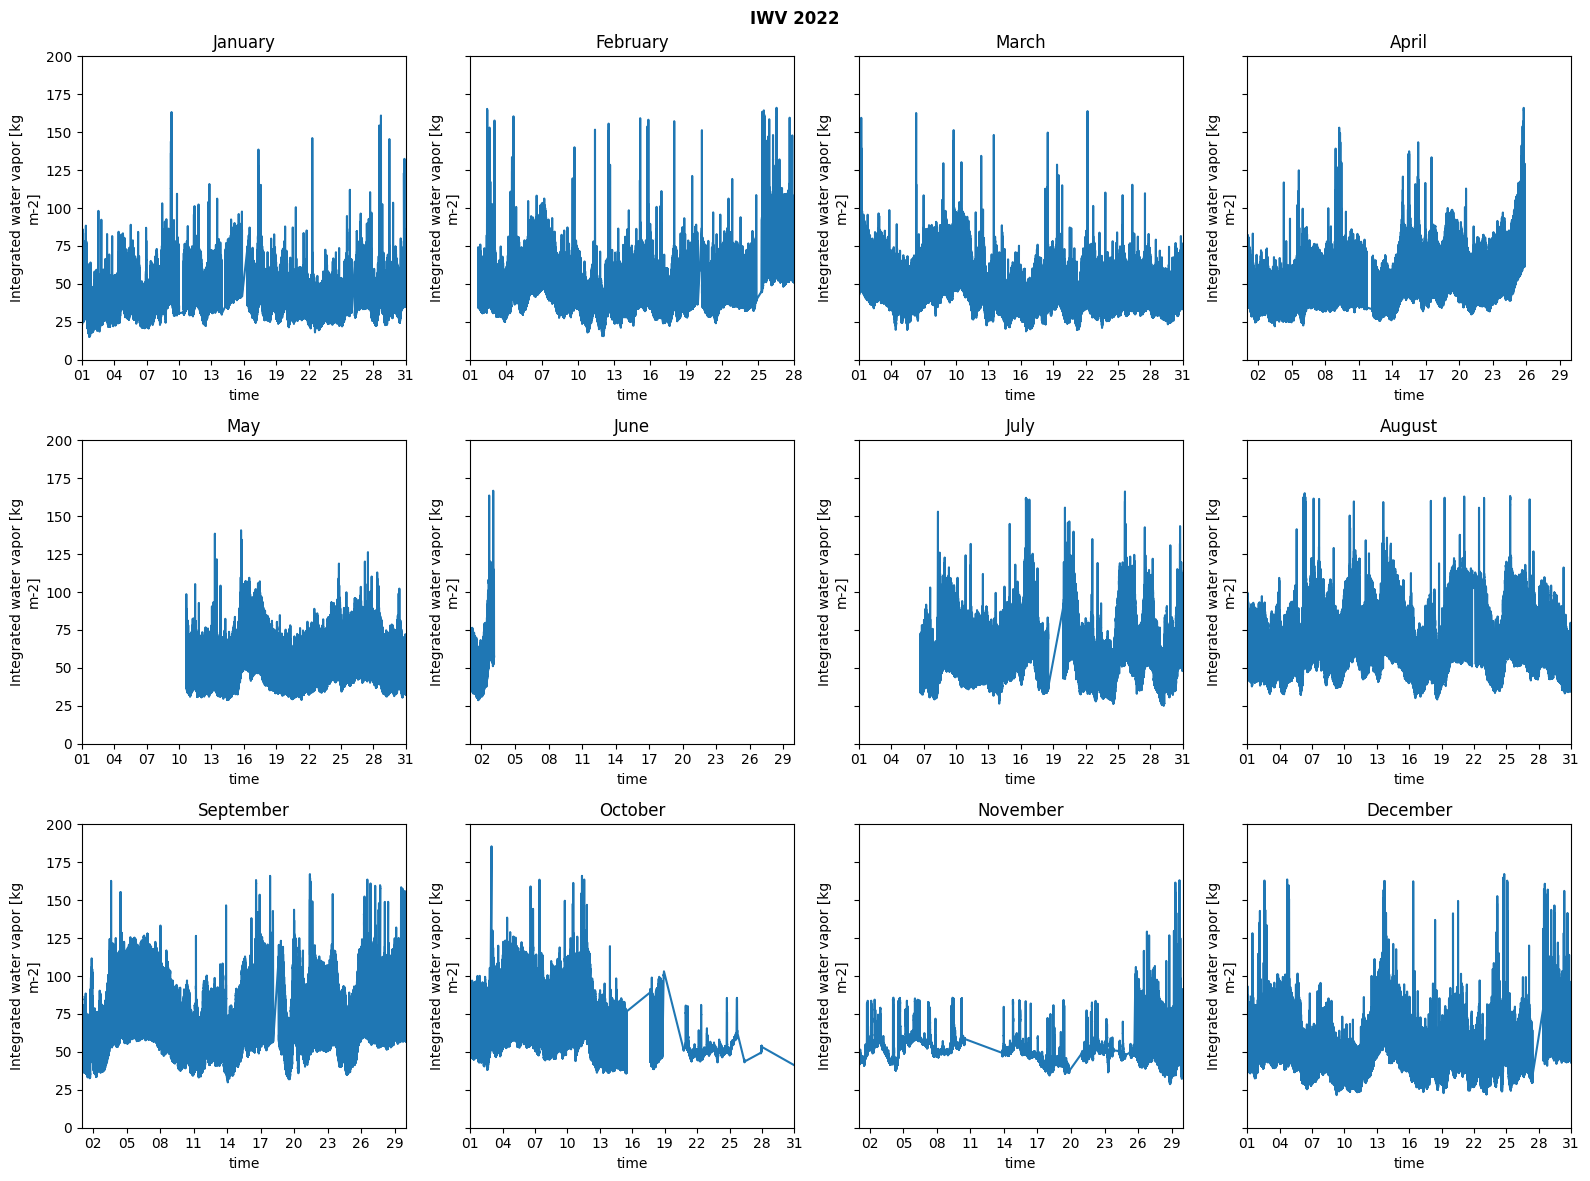

In [60]:
# Select year.
year = 2022
iwv_2022 = IWV.sel(time=str(year))

# Group by month
groups = iwv_2022.groupby('time.month')

# Create faceted plots manually.
fig, axes = plt.subplots(3, 4, figsize=(16, 12), sharey=True)
axes = axes.flatten()

# Plot each month
for month, ax in zip(range(1, 13), axes):

    # First and last day of month.
    start_date = np.datetime64(f'{year}-{month:02d}-01')
    last_day = calendar.monthrange(year, month)[1]
    end_date = np.datetime64(f'{year}-{month:02d}-{last_day:02d}')

    # If month exists.
    if month in groups.groups:
        groups[month].plot(ax=ax, x='time')

    else:
        ax.text(
            0.5, 0.5,
            'No Data',
            ha='center',
            va='center',
            transform=ax.transAxes
        )

    # Axis formatting.
    ax.set_xlim(start_date, end_date)
    ax.set_ylim(0, 200)
    ax.set_title(calendar.month_name[month], fontweight='medium')

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))

fig.suptitle(f'IWV {year}', fontweight='bold')

plt.tight_layout()
plt.show()

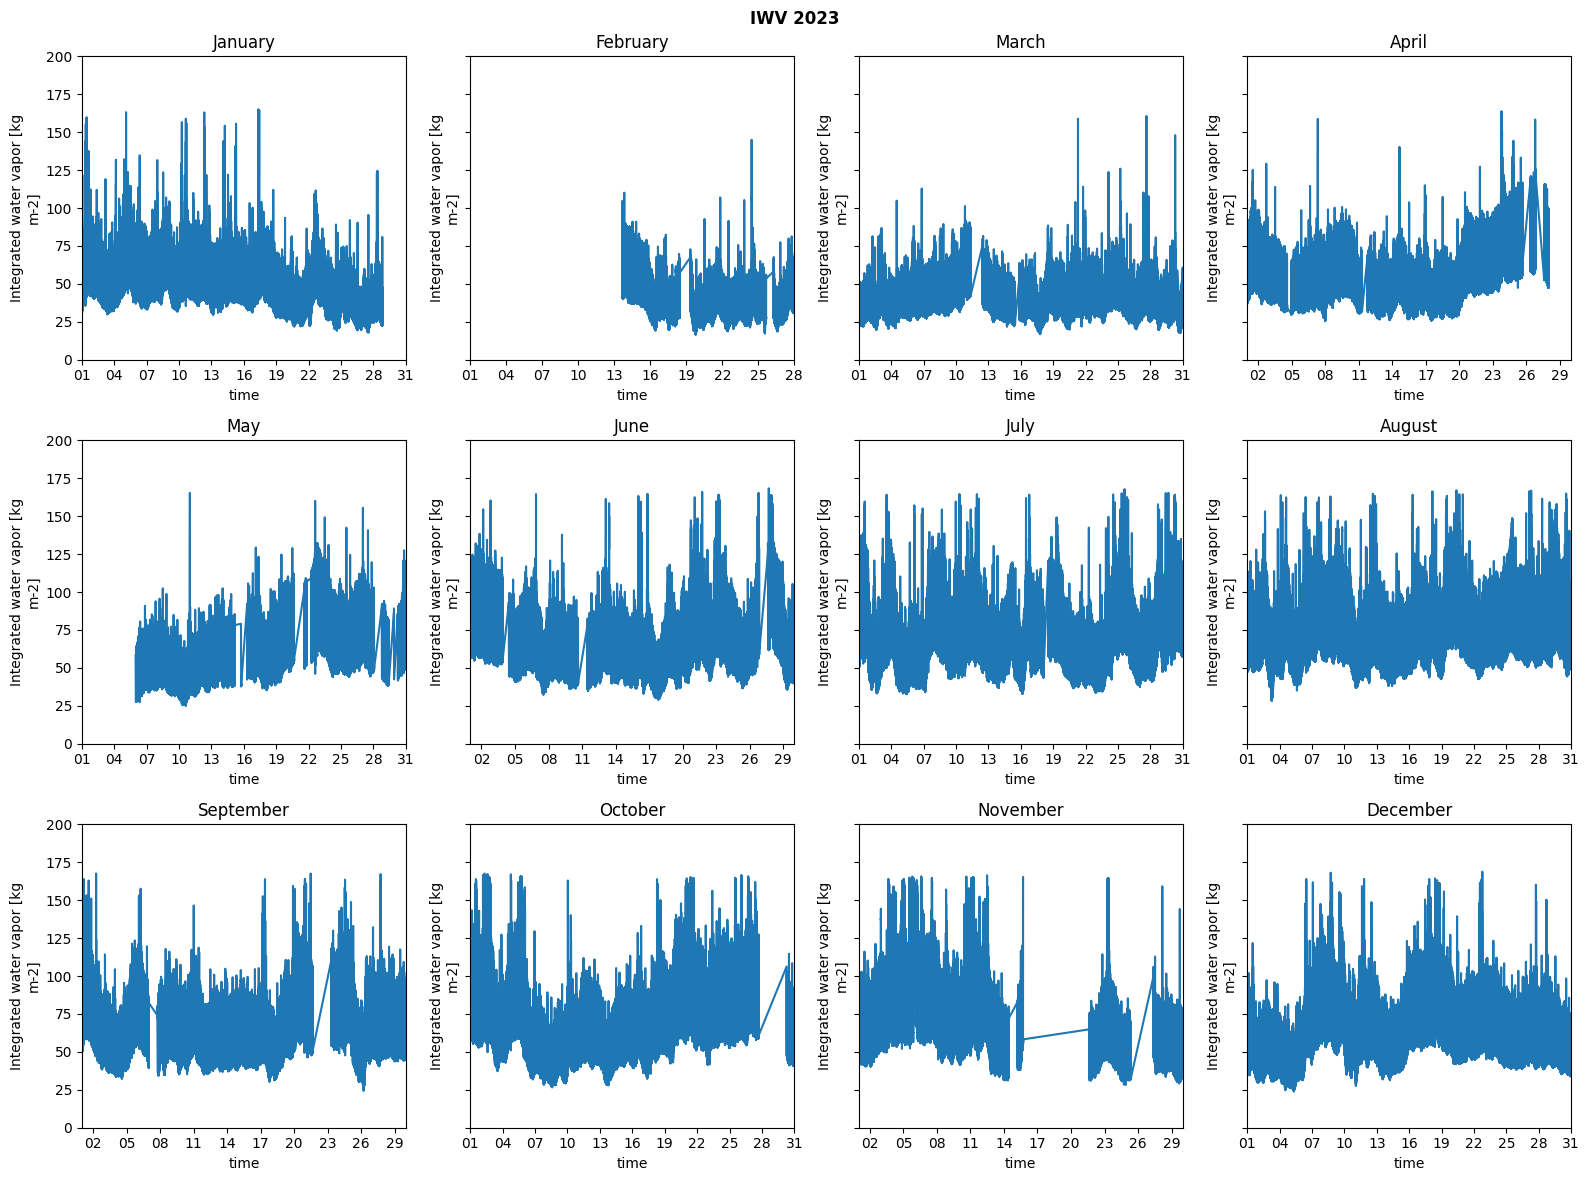

In [61]:
# Select year.
year = 2023
iwv_2023 = IWV.sel(time=str(year))

# Group by month
groups = iwv_2023.groupby('time.month')

# Create faceted plots manually.
fig, axes = plt.subplots(3, 4, figsize=(16, 12), sharey=True)
axes = axes.flatten()

# Plot each month
for month, ax in zip(range(1, 13), axes):

    # First and last day of month.
    start_date = np.datetime64(f'{year}-{month:02d}-01')
    last_day = calendar.monthrange(year, month)[1]
    end_date = np.datetime64(f'{year}-{month:02d}-{last_day:02d}')

    # If month exists.
    if month in groups.groups:
        groups[month].plot(ax=ax, x='time')

    else:
        ax.text(
            0.5, 0.5,
            'No Data',
            ha='center',
            va='center',
            transform=ax.transAxes
        )

    # Axis formatting.
    ax.set_xlim(start_date, end_date)
    ax.set_ylim(0, 200)
    ax.set_title(calendar.month_name[month], fontweight='medium')

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))

fig.suptitle(f'IWV {year}', fontweight='bold')

plt.tight_layout()
plt.show()

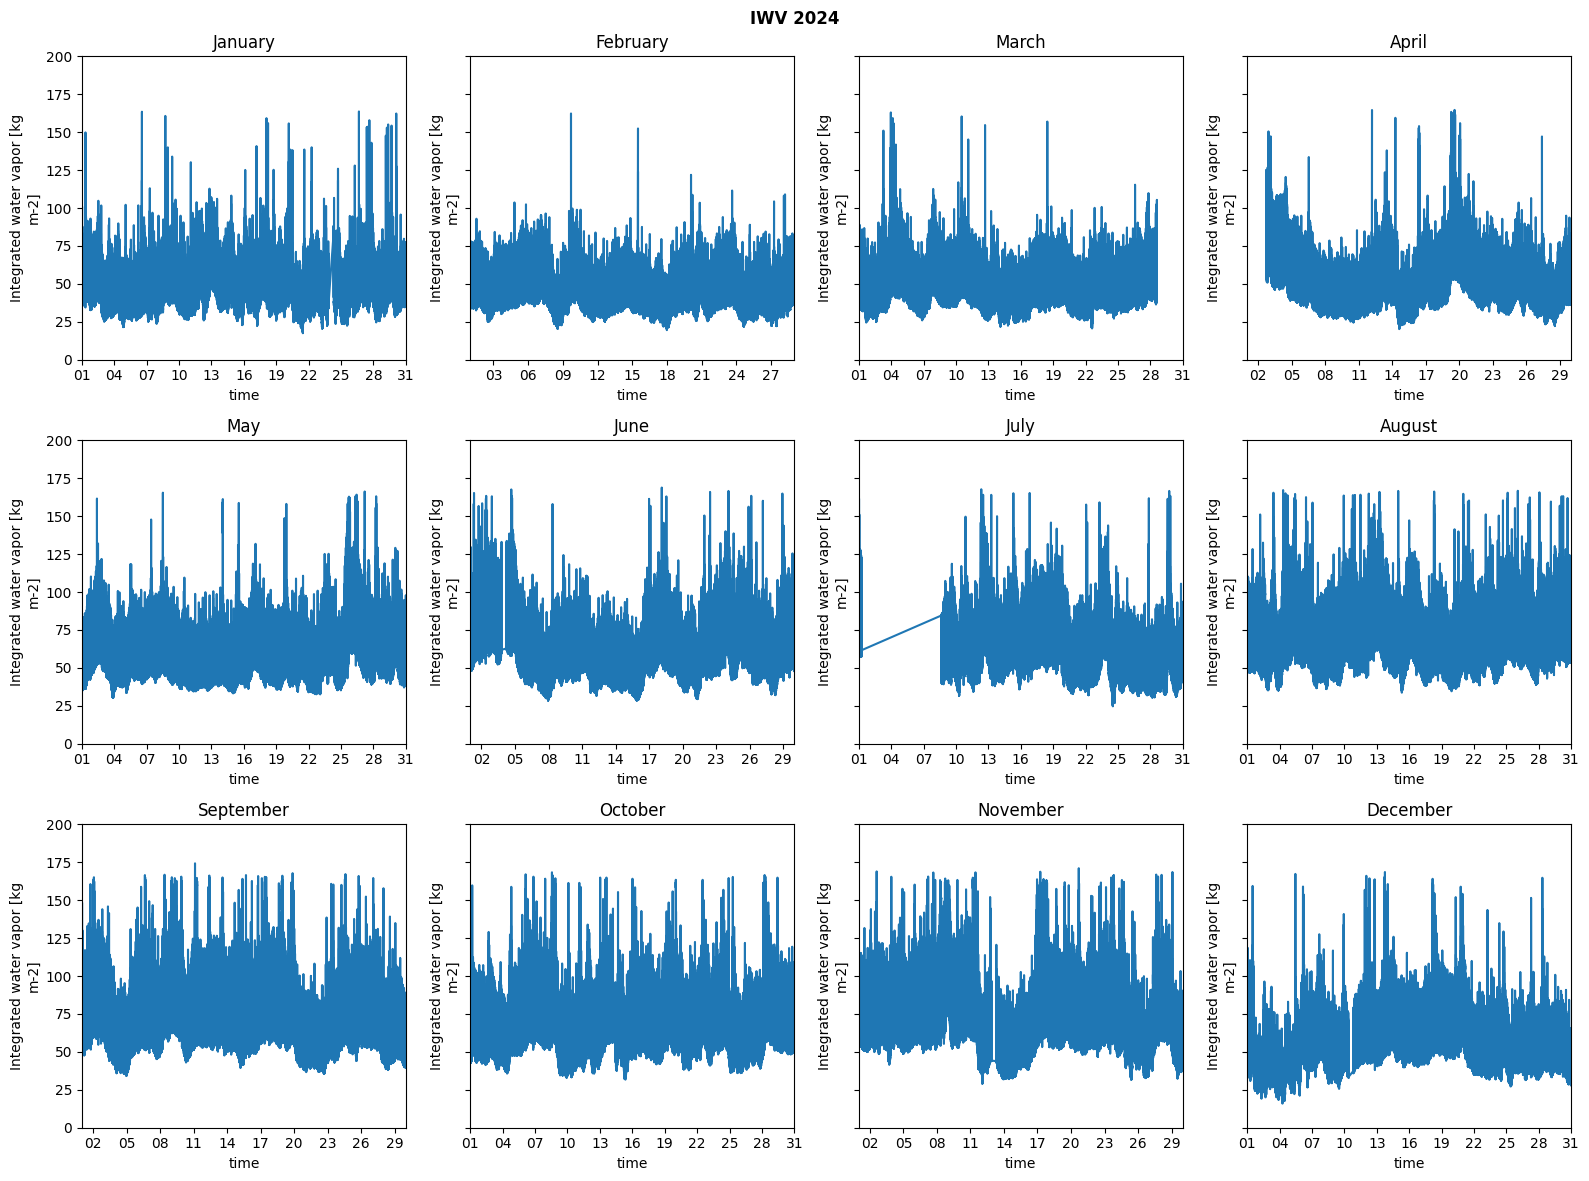

In [62]:
# Select year.
year = 2024
iwv_2024 = IWV.sel(time=str(year))

# Group by month
groups = iwv_2024.groupby('time.month')

# Create faceted plots manually.
fig, axes = plt.subplots(3, 4, figsize=(16, 12), sharey=True)
axes = axes.flatten()

# Plot each month
for month, ax in zip(range(1, 13), axes):

    # First and last day of month.
    start_date = np.datetime64(f'{year}-{month:02d}-01')
    last_day = calendar.monthrange(year, month)[1]
    end_date = np.datetime64(f'{year}-{month:02d}-{last_day:02d}')

    # If month exists.
    if month in groups.groups:
        groups[month].plot(ax=ax, x='time')

    else:
        ax.text(
            0.5, 0.5,
            'No Data',
            ha='center',
            va='center',
            transform=ax.transAxes
        )

    # Axis formatting.
    ax.set_xlim(start_date, end_date)
    ax.set_ylim(0, 200)
    ax.set_title(calendar.month_name[month], fontweight='medium')

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))

fig.suptitle(f'IWV {year}', fontweight='bold')

plt.tight_layout()
plt.show()

MemoryError: Unable to allocate 119. MiB for an array with shape (15567083,) and data type datetime64[ns]

In [63]:
# Select year.
year = 2025
iwv_202 = IWV.sel(time=str(year))

# Group by month
groups = iwv_202.groupby('time.month')

# Create faceted plots manually.
fig, axes = plt.subplots(3, 4, figsize=(16, 12), sharey=True)
axes = axes.flatten()

# Plot each month
for month, ax in zip(range(1, 13), axes):

    # First and last day of month.
    start_date = np.datetime64(f'{year}-{month:02d}-01')
    last_day = calendar.monthrange(year, month)[1]
    end_date = np.datetime64(f'{year}-{month:02d}-{last_day:02d}')

    # If month exists.
    if month in groups.groups:
        groups[month].plot(ax=ax, x='time')

    else:
        ax.text(
            0.5, 0.5,
            'No Data',
            ha='center',
            va='center',
            transform=ax.transAxes
        )

    # Axis formatting.
    ax.set_xlim(start_date, end_date)
    ax.set_ylim(0, 200)
    ax.set_title(calendar.month_name[month], fontweight='medium')

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))

fig.suptitle(f'IWV {year}', fontweight='bold')

plt.tight_layout()
plt.show()

MemoryError: 

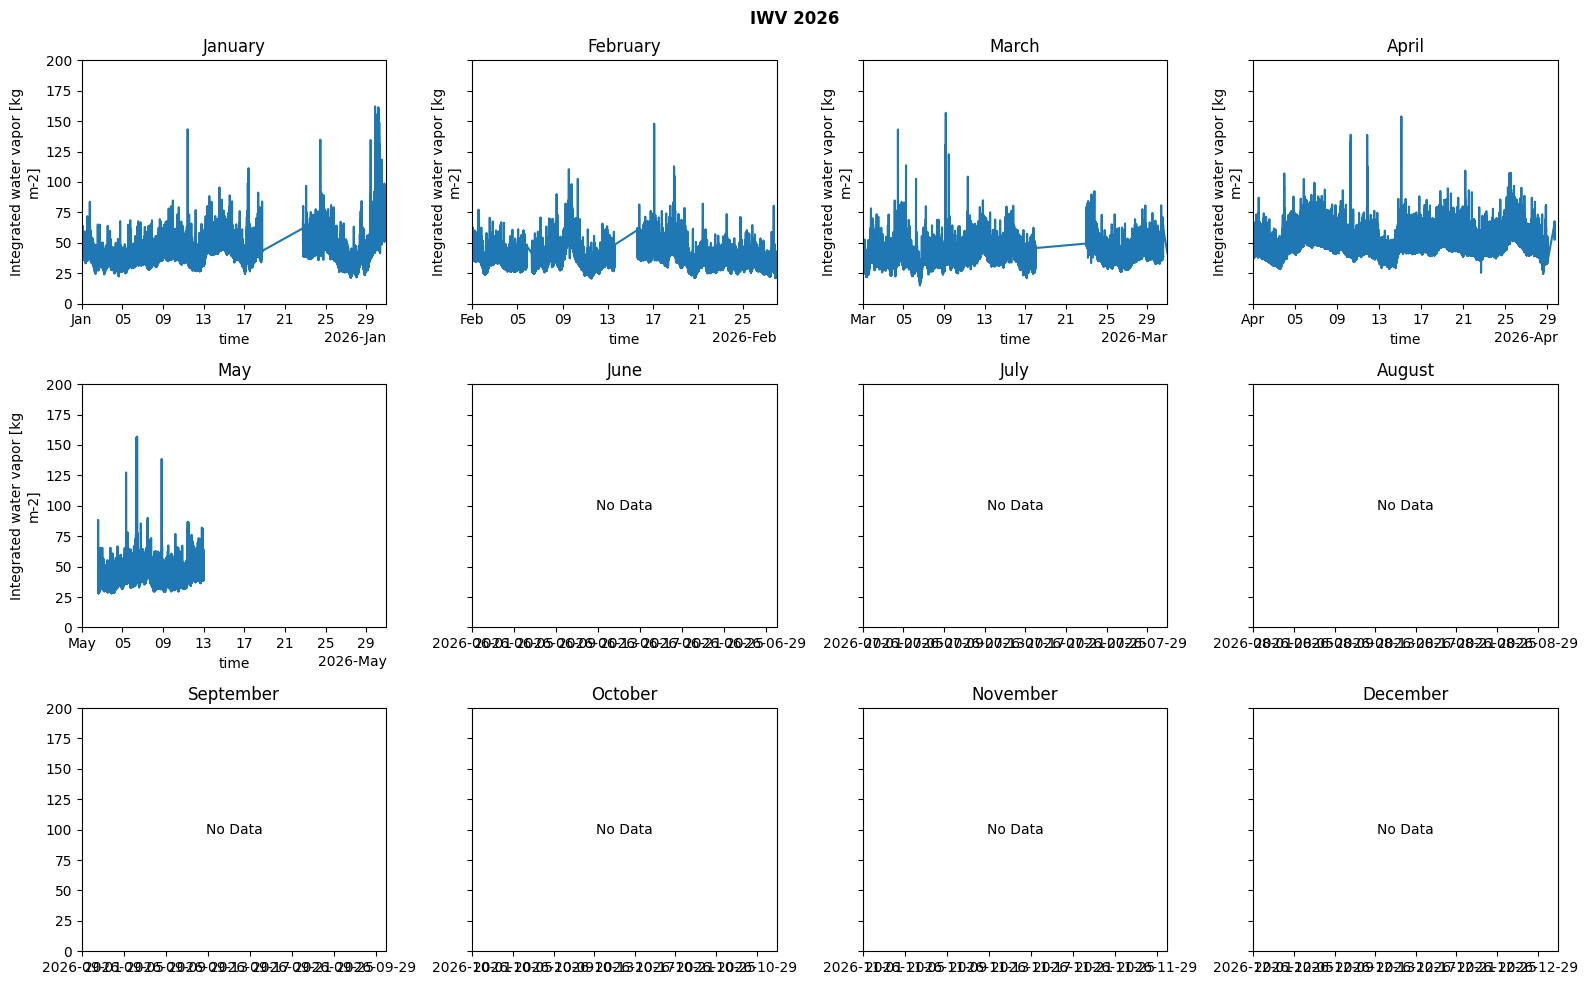

In [45]:
# Select year.
year = 2026
iwv_2025 = IWV.sel(time=str(year))

# Group by month
groups = iwv_2025.groupby('time.month')

# Create faceted plots manually.
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharey=True)
axes = axes.flatten()

# Plot each month
for month, ax in zip(range(1, 13), axes):
    # First and last day of month.
    start_date = np.datetime64(f'{year}-{month:02d}-01')
    last_day = calendar.monthrange(year, month)[1]
    end_date = np.datetime64(f'{year}-{month:02d}-{last_day:02d}')

    # If month exists.
    if month in groups.groups:
        groups[month].plot(ax=ax, x='time')

    else:
        ax.text(
            0.5, 0.5,
            'No Data',
            ha='center',
            va='center',
            transform=ax.transAxes
        )

    ax.set_title(calendar.month_name[month], fontweight='medium')
    ax.set_ylim(0, 200)
    ax.set_xlim(start_date, end_date)

fig.suptitle(f'IWV {year}', fontweight='bold')

plt.tight_layout()
plt.show()

### Big Spike

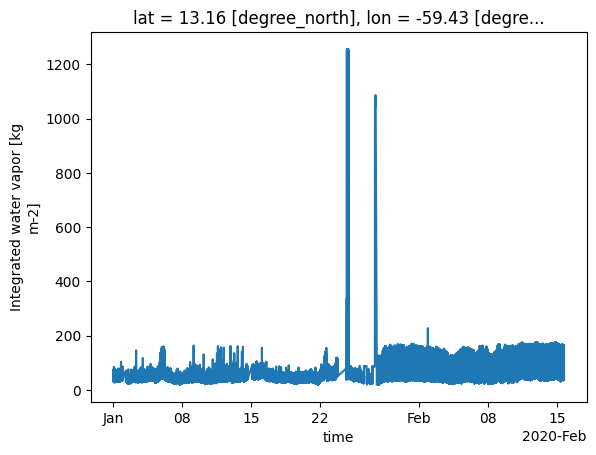

In [41]:
big_spike_time: slice = slice("2020-01", "2020-02")
IWV.sel(time=big_spike_time).plot(x="time")

The range of IWV values is much larger after the second big spike than before.

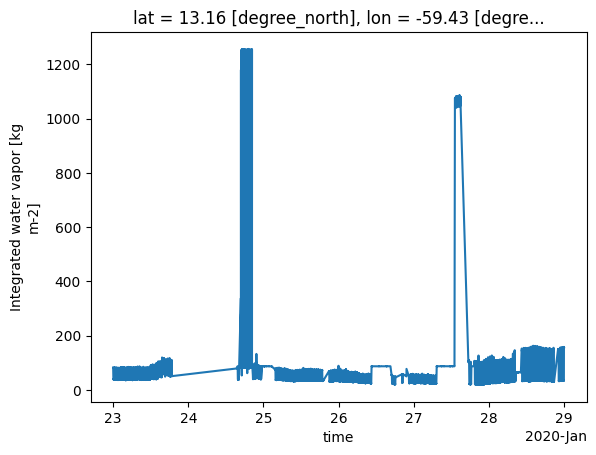

In [44]:
big_spike_time_zoom: slice = slice("2020-01-23", "2020-01-28")
IWV.sel(time=big_spike_time_zoom).plot(x="time")

# Check time differences

In [7]:
import pandas as pd
import numpy as np

time_diff = ds.time.diff('time')

print(time_diff.min().values / 1_000_000_000)
print(time_diff.max().values / 1_000_000_000)
print(time_diff.mean().values/ 1_000_000_000)

1 nanoseconds
44606001 nanoseconds
2 nanoseconds


## Duplicates

In [9]:
duplicates = ds.get_index('time').duplicated().sum()
print(duplicates)

0


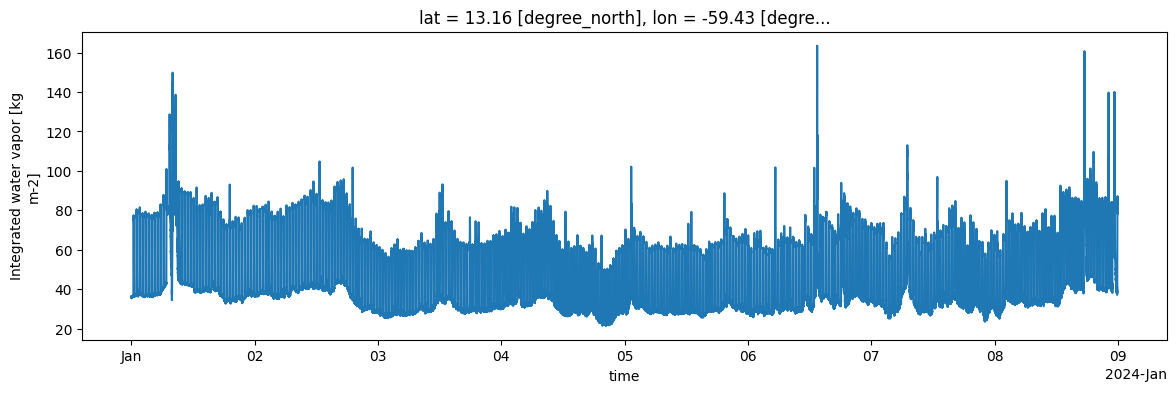

In [10]:
subset = ds.sel(time=slice('2024-01-01', '2024-01-08'))

subset['IWV'].plot(figsize=(14,4))

## Basic Statistics

In [11]:
iwv = ds['IWV']

print(iwv.min().compute().values)
print(iwv.max().compute().values)
print(iwv.mean().compute().values)
print(iwv.std().compute().values)

1.2317121
1256.4982
43.197704
16.036951


# Rain Flag

In [14]:
ds['RF'].values

array([0, 0, 0, ..., 0, 0, 0], dtype=int8)

In [15]:
rainy = ds.where(ds.RF == 1)
clear = ds.where(ds.RF == 0)

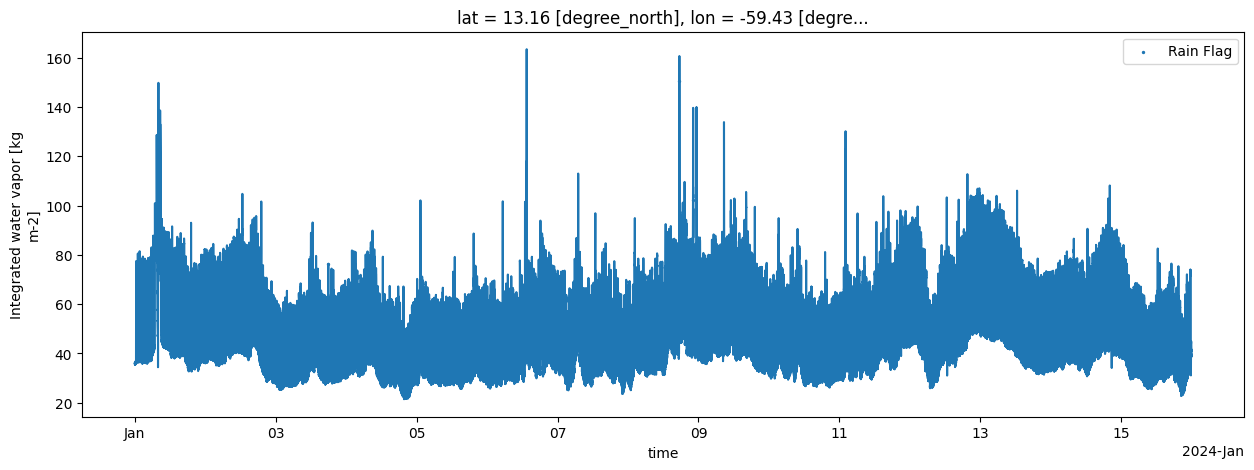

In [18]:
subset = ds.sel(time=slice('2024-01-01', '2024-01-15'))

fig, ax = plt.subplots(figsize=(15,5))

subset['IWV'].plot(ax=ax)

rainy = subset.where(subset.RF == 1)

ax.scatter(
    rainy.time,
    rainy.IWV,
    s=2,
    label='Rain Flag'
)

ax.legend()

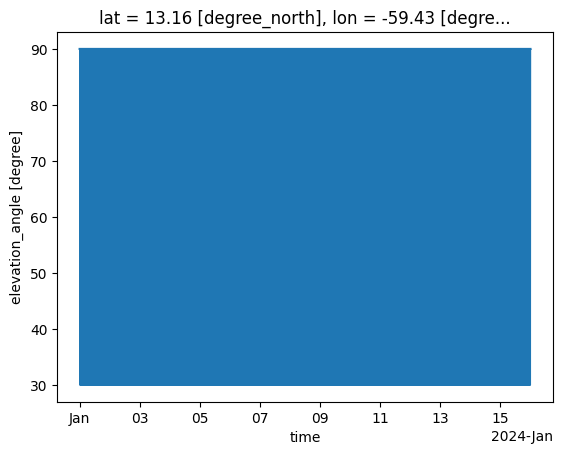

In [20]:
subset['ELE'].plot()